## Extra: Global U+V Random Forest
**Purpose:** Build a single global model that predicts both `U` and `V` jointly from merged processed subsets.  
**Inputs:** `../data/processed/clean_data_train_*.csv` and `../data/processed/clean_data_test_*.csv`.  
**Notes:** `U` rows use `atom_j = atom_i` (on-site). `target_type` is kept only for evaluation grouping — it is **not** used as a regressor.  
**Outputs:** global-model metrics, diagnostic plot, `../data/processed/predictions_uv_rf.csv`, and `../data/processed/rf_uv_feature_importance.csv`.


In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.stats import norm
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from aux_functions import evaluate_regression

RANDOM_STATE = 100
base = Path('../data/processed')

df_u_train = pd.read_csv(base / 'clean_data_train_u.csv')
df_u_test = pd.read_csv(base / 'clean_data_test_u.csv')
df_v_train = pd.read_csv(base / 'clean_data_train_v.csv')
df_v_test = pd.read_csv(base / 'clean_data_test_v.csv')

print('Loaded processed U and V datasets.')

Loaded processed U and V datasets.


In [11]:
def _prepare_u(df):
    out = df.copy()
    if 'Unnamed: 0' in out.columns:
        out = out.drop(columns=['Unnamed: 0'])
    out['target_type'] = 'U'
    out['target_value'] = out['U']
    out['distance'] = 0.0
    out['ddec_charge_j'] = 0.0
    # On-site U: same site for i and j (no distinct neighbor in U table)
    out['atom_j'] = out['atom_i'].astype(str)
    return out[['qmof_id', 'pld', 'density', 'volume', 'ddec_charge_i', 'ddec_charge_j', 'distance', 'atom_i', 'atom_j', 'target_type', 'target_value']]

def _prepare_v(df):
    out = df.copy()
    if 'Unnamed: 0' in out.columns:
        out = out.drop(columns=['Unnamed: 0'])
    out['target_type'] = 'V'
    out['target_value'] = out['V']
    return out[['qmof_id', 'pld', 'density', 'volume', 'ddec_charge_i', 'ddec_charge_j', 'distance', 'atom_i', 'atom_j', 'target_type', 'target_value']]

uv_train = pd.concat([_prepare_u(df_u_train), _prepare_v(df_v_train)], axis=0, ignore_index=True)
uv_test = pd.concat([_prepare_u(df_u_test), _prepare_v(df_v_test)], axis=0, ignore_index=True)

print('Global train rows:', len(uv_train))
print('Global test rows:', len(uv_test))
print(uv_train['target_type'].value_counts())

Global train rows: 186007
Global test rows: 42585
target_type
V    178924
U      7083
Name: count, dtype: int64


In [13]:
uv_test

,qmof_id,pld,density,volume,ddec_charge_i,ddec_charge_j,distance,atom_i,atom_j,target_type,target_value
0,qmof-04b4379,4.43754,1.258196,617.215219,-0.837793,0.000000,0.000000,O,O,U,8.0717
1,qmof-04b4379,4.43754,1.258196,617.215219,-0.814373,0.000000,0.000000,O,O,U,8.0717
2,qmof-04b4379,4.43754,1.258196,617.215219,-0.814397,0.000000,0.000000,O,O,U,7.6567
3,qmof-04b4379,4.43754,1.258196,617.215219,0.755900,0.000000,0.000000,O,O,U,7.6569
4,qmof-0798d7e,11.55056,0.556745,8298.483612,2.086122,0.000000,0.000000,Hf,Hf,U,2.7092
...,...,...,...,...,...,...,...,...,...,...,...
42580,qmof-fd5026b,7.19662,0.999235,4488.287409,0.420259,-0.641787,9.761275,O,O,V,0.0256
42581,qmof-fd5026b,7.19662,0.999235,4488.287409,0.420259,-0.633233,10.264423,O,O,V,0.0485
42582,qmof-fd5026b,7.19662,0.999235,4488.287409,0.420259,-0.632231,10.264611,O,O,V,0.0486
42583,qmof-fd5026b,7.19662,0.999235,4488.287409,0.420259,-0.641979,15.994698,O,O,V,0.0122


In [14]:
# Exclude target_type from X — it would leak U vs V identity
train_for_dummies = uv_train.drop(columns=['qmof_id', 'target_type'])
test_for_dummies = uv_test.drop(columns=['qmof_id', 'target_type'])

train_dummies = pd.get_dummies(train_for_dummies, columns=['atom_i', 'atom_j'], dtype=int, drop_first=True)
test_dummies = pd.get_dummies(test_for_dummies, columns=['atom_i', 'atom_j'], dtype=int, drop_first=True)

target_col = 'target_value'
predictor_cols = [c for c in train_dummies.columns if c != target_col]

X_train = train_dummies[predictor_cols].copy()
y_train = train_dummies[target_col].copy().reset_index(drop=True)
X_test = test_dummies.reindex(columns=predictor_cols, fill_value=0).copy()
y_test = test_dummies[target_col].copy().reset_index(drop=True)

print(f'Shape of X train data: {X_train.shape}')
print(f'Shape of y train data: {y_train.shape}')
print(f'Shape of X test data: {X_test.shape}')
print(f'Shape of y test data: {y_test.shape}')

Shape of X train data: (186007, 58)
Shape of y train data: (186007,)
Shape of X test data: (42585, 58)
Shape of y test data: (42585,)


In [16]:
param_grid_rf = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10],
    'max_features': ['sqrt', 0.6],
    'min_samples_leaf': [10, 30],
}

rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid=param_grid_rf,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=1,
    n_jobs=-1,
)

rf_grid.fit(X_train, y_train)
print('Best RF params (global U+V):', rf_grid.best_params_)
rf_uv_best = rf_grid.best_estimator_

metrics_uv_rf = evaluate_regression(rf_uv_best, X_train, y_train, X_test, y_test)
metrics_uv_rf

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best RF params (global U+V): {'max_depth': 10, 'max_features': 0.6, 'min_samples_leaf': 30, 'n_estimators': 300}
Training RMSE: 0.1160
Training R²: 0.9934
Training MAE: 0.0327
Test RMSE: 0.1077
Test R²: 0.9943
Test MAE: 0.0328


{'rmse_train': np.float64(0.11601199051479591),
 'r2_train': 0.9934218223091569,
 'mae_train': 0.03273610076907567,
 'rmse_test': np.float64(0.10771555235657329),
 'r2_test': 0.9943347973730713,
 'mae_test': 0.03276198251854544}

/var/folders/dw/9pmjncps47q2gq34yw1xhwvw0000gn/T/ipykernel_34162/4126883484.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


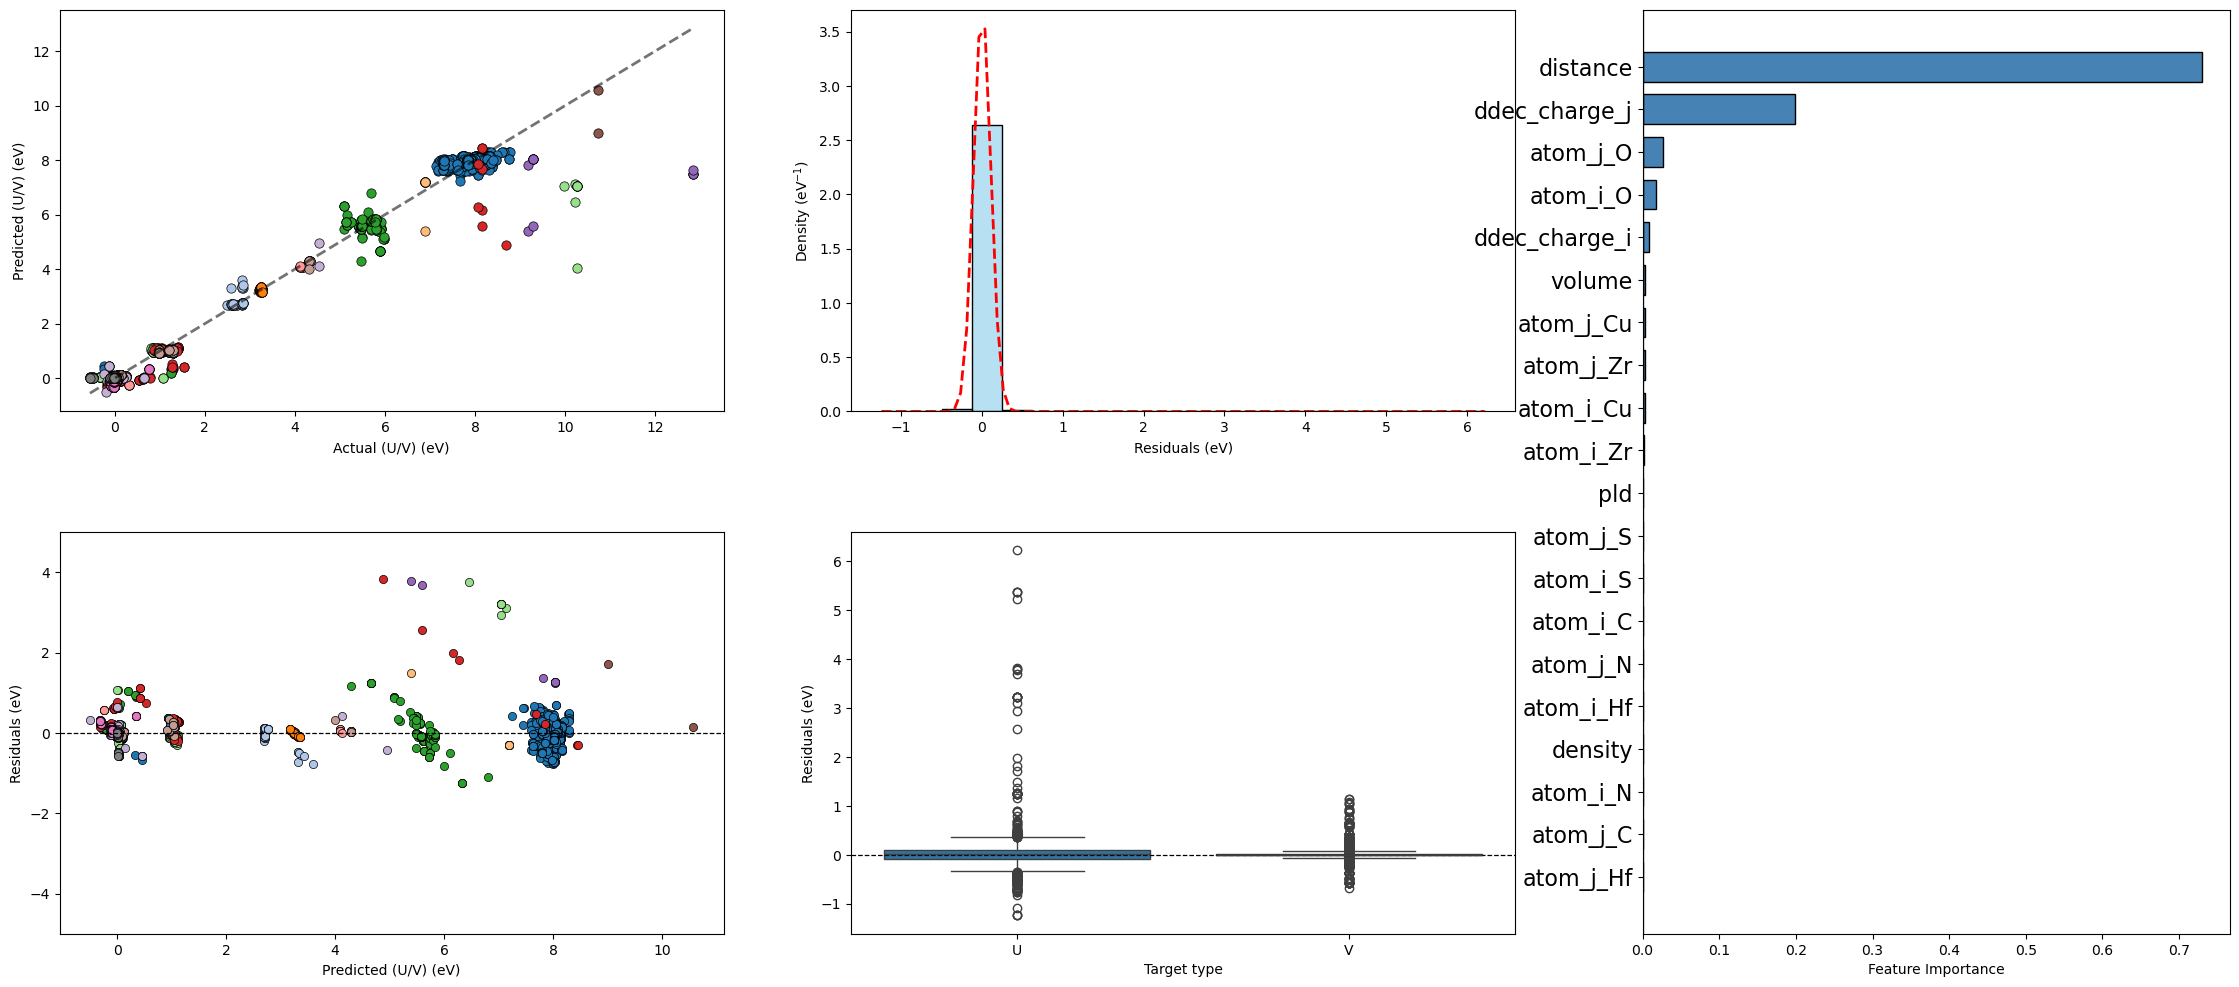

In [17]:
y_pred = pd.Series(rf_uv_best.predict(X_test)).reset_index(drop=True)
y_true = y_test.reset_index(drop=True)
residuals = y_true - y_pred
elem_i = uv_test['atom_i'].astype(str).reset_index(drop=True)
kind = uv_test['target_type'].reset_index(drop=True)

atoms = pd.Index(elem_i.dropna().unique())
palette = (sns.color_palette('tab20', 20) + sns.color_palette('tab20b', 20) + sns.color_palette('tab20c', 20))[:len(atoms)]
color_map = dict(zip(atoms, palette))

fig = plt.figure(figsize=(28, 12))
gs = GridSpec(2, 3, figure=fig, width_ratios=[1.3, 1.3, 1.15], wspace=0.2, hspace=0.3)
ax_parity = fig.add_subplot(gs[0, 0])
ax_hist = fig.add_subplot(gs[0, 1])
ax_resid = fig.add_subplot(gs[1, 0])
ax_box = fig.add_subplot(gs[1, 1])
ax_imp = fig.add_subplot(gs[:, 2])

for atom in atoms:
    mask = (elem_i.values == atom)
    if mask.any():
        ax_parity.scatter(y_true[mask], y_pred[mask], color=color_map.get(atom, 'gray'), edgecolor='k', s=45, linewidths=0.5)

lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
ax_parity.plot([lo, hi], [lo, hi], 'k--', lw=2, alpha=0.55)
ax_parity.set_xlabel('Actual (U/V) (eV)')
ax_parity.set_ylabel('Predicted (U/V) (eV)')

sns.histplot(residuals, bins=20, kde=False, stat='density', color='skyblue', alpha=0.6, ax=ax_hist)
mu, sigma = norm.fit(residuals)
x = np.linspace(residuals.min(), residuals.max(), 100)
ax_hist.plot(x, norm.pdf(x, mu, sigma), 'r--', lw=2)
ax_hist.set_xlabel('Residuals (eV)')
ax_hist.set_ylabel('Density (eV$^{-1}$)')

for atom in atoms:
    mask = (elem_i.values == atom)
    if mask.any():
        ax_resid.scatter(y_pred[mask], residuals[mask], color=color_map.get(atom, 'gray'), edgecolor='k', s=35, linewidths=0.5)
ax_resid.axhline(0, color='black', lw=0.9, linestyle='--')
ax_resid.set_xlabel('Predicted (U/V) (eV)')
ax_resid.set_ylabel('Residuals (eV)')
ax_resid.set_ylim(-5, 5)

box_df = pd.DataFrame({'residual': residuals, 'target_type': kind})
sns.boxplot(x='target_type', y='residual', data=box_df, ax=ax_box)
ax_box.axhline(0, color='black', lw=0.9, linestyle='--')
ax_box.set_xlabel('Target type')
ax_box.set_ylabel('Residuals (eV)')

fi = pd.DataFrame({'feature': X_train.columns, 'importance': rf_uv_best.feature_importances_}).sort_values('importance', ascending=True).tail(20)
yp = np.arange(len(fi))
ax_imp.barh(yp, fi['importance'].values, color='steelblue', edgecolor='k', height=0.7)
ax_imp.set_yticks(yp)
ax_imp.set_yticklabels(fi['feature'].values, fontsize=16)
ax_imp.set_xlabel('Feature Importance')
ax_imp.axvline(0, color='black', lw=0.9)

plt.tight_layout()
plt.show()

In [6]:
out_dir = Path('../data/processed')
out_dir.mkdir(parents=True, exist_ok=True)

pred_uv_rf = pd.DataFrame({
    'qmof_id': uv_test['qmof_id'].reset_index(drop=True),
    'target_type': kind,
    'actual': y_true,
    'predicted': y_pred,
    'residual': residuals,
    'atom_i': uv_test['atom_i'].reset_index(drop=True),
    'atom_j': uv_test['atom_j'].reset_index(drop=True),
})
pred_uv_rf.to_csv(out_dir / 'predictions_uv_rf.csv', index=False)

rf_uv_fi = pd.DataFrame({'feature': X_train.columns, 'importance': rf_uv_best.feature_importances_}).sort_values('importance', ascending=False)
rf_uv_fi.to_csv(out_dir / 'rf_uv_feature_importance.csv', index=False)

print(f"Saved: {out_dir / 'predictions_uv_rf.csv'} ({len(pred_uv_rf)} rows)")
print(f"Saved: {out_dir / 'rf_uv_feature_importance.csv'} ({len(rf_uv_fi)} rows)")

Saved: ../data/processed/predictions_uv_rf.csv (42585 rows)
Saved: ../data/processed/rf_uv_feature_importance.csv (60 rows)
